# MNIST Digit Classification Training

This notebook imports the model from model.py and trains it on MNIST data


In [3]:
# Add model from Git Repo
!git clone https://github.com/SachinDangayach/AU_6_NN_99_4.git

Cloning into 'AU_6_NN_99_4'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 19 (delta 6), reused 19 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 343.51 KiB | 13.74 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [12]:
# Core PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchsummary import summary
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import sys

# Add the cloned repository directory to the Python path
sys.path.append('/content/AU_6_NN_99_4')

# Import our custom model
from model_1 import Net, get_model_summary

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✅ All imports successful!
PyTorch version: 2.8.0+cu126
CUDA available: True


In [13]:
# Device configuration
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

print(f"🖥️  Device: {device}")
if use_cuda:
    print(f"🚀 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("💻 Using CPU")

# Create model instance
model = Net().to(device)
print(get_model_summary())

summary(model, input_size=(1, 28, 28))

🖥️  Device: cuda
🚀 GPU: Tesla T4
💾 GPU Memory: 15.8 GB

Model Summary:
- Parameters: 194,884 (trainable: 194,884)
- Input: (batch_size, 1, 28, 28)
- Output: (batch_size, 10)
- Architecture: CNN with ReLU, MaxPool2d, 1x1 convs
- Final RF: 28x28 (covers full input)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 26, 26]             288
              ReLU-2           [-1, 32, 26, 26]               0
            Conv2d-3           [-1, 64, 24, 24]          18,432
              ReLU-4           [-1, 64, 24, 24]               0
            Conv2d-5          [-1, 128, 22, 22]          73,728
              ReLU-6          [-1, 128, 22, 22]               0
         MaxPool2d-7          [-1, 128, 11, 11]               0
            Conv2d-8           [-1, 32, 11, 11]           4,096
              ReLU-9           [-1, 32, 11, 11]               0
           Conv2d-10          

In [14]:
# Data loading and preprocessing
BATCH_SIZE = 64
NUM_WORKERS = 2 if use_cuda else 0
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,))
])

kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': True if use_cuda else False,
    'persistent_workers': True if NUM_WORKERS > 0 else False
}

# Load datasets
train_dataset = datasets.MNIST(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    **kwargs
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **kwargs
)

print(f"✅ Dataset loaded successfully!")
print(f"📚 Training samples: {len(train_dataset):,}")
print(f"🧪 Test samples: {len(test_dataset):,}")


✅ Dataset loaded successfully!
📚 Training samples: 60,000
🧪 Test samples: 10,000


In [15]:
# Training and testing functions
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch}')

    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct_predictions += pred.eq(target.view_as(pred)).sum().item()
        total_samples += target.size(0)

        current_acc = 100. * correct_predictions / total_samples
        pbar.set_description(
            f'Epoch {epoch} | Loss: {loss.item():.4f} | Acc: {current_acc:.2f}%'
        )

    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct_predictions / len(train_loader.dataset)
    return avg_loss, accuracy


def test(model, device, test_loader):
    model.eval()
    test_loss = 0.0
    correct_predictions = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct_predictions += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct_predictions / len(test_loader.dataset)

    print(f'\n📊 Test Results:')
    print(f'   Loss: {test_loss:.4f}')
    print(f'   Accuracy: {correct_predictions}/{len(test_loader.dataset)} ({accuracy:.2f}%)')

    return correct_predictions, test_loss, accuracy

print("✅ Training and testing functions defined!")


✅ Training and testing functions defined!


In [16]:
# Training configuration
LEARNING_RATE = 0.01
MOMENTUM = 0.9
MAX_EPOCHS = 20
TARGET_ACCURACY = 99.4
PATIENCE = 10

optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

print(f"🚀 Training Configuration:")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Momentum: {MOMENTUM}")
print(f"   Max Epochs: {MAX_EPOCHS}")
print(f"   Target Accuracy: {TARGET_ACCURACY}%")

# Metrics tracking
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
epochs = []

best_accuracy = 0.0
patience_counter = 0
best_model_state = None


🚀 Training Configuration:
   Learning Rate: 0.01
   Momentum: 0.9
   Max Epochs: 20
   Target Accuracy: 99.4%


In [17]:
# Training loop
print(f"\n🎯 Starting Training...")
print("=" * 60)

for epoch in range(1, MAX_EPOCHS + 1):
    print(f"\n📈 Epoch {epoch}/{MAX_EPOCHS}")
    print("-" * 40)

    # Train the model
    train_loss, train_acc = train(model, device, train_loader, optimizer, epoch)

    # Evaluate on test set
    correct, test_loss, test_acc = test(model, device, test_loader)

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    epochs.append(epoch)

    # Check for best model
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"🎉 New best accuracy: {best_accuracy:.2f}%")
    else:
        patience_counter += 1

    # Early stopping check
    if test_acc >= TARGET_ACCURACY:
        print(f"\n🏆 Target accuracy achieved! ({test_acc:.2f}% >= {TARGET_ACCURACY}%)")
        break

    if patience_counter >= PATIENCE and epoch > 5:
        print(f"\n⏹️  Early stopping triggered (no improvement for {PATIENCE} epochs)")
        break

print(f"\n✅ Training completed!")
print(f"📊 Final Results:")
print(f"   Best Accuracy: {best_accuracy:.2f}%")
print(f"   Total Epochs: {len(epochs)}")

# Load best model state
if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"🔄 Loaded best model state (accuracy: {best_accuracy:.2f}%)")



🎯 Starting Training...

📈 Epoch 1/20
----------------------------------------


Epoch 1 | Loss: 0.0579 | Acc: 80.86%: 100%|██████████| 938/938 [00:16<00:00, 55.32it/s]



📊 Test Results:
   Loss: 0.0870
   Accuracy: 9718/10000 (97.18%)
🎉 New best accuracy: 97.18%

📈 Epoch 2/20
----------------------------------------


Epoch 2 | Loss: 0.0452 | Acc: 97.43%: 100%|██████████| 938/938 [00:16<00:00, 55.57it/s]



📊 Test Results:
   Loss: 0.0584
   Accuracy: 9810/10000 (98.10%)
🎉 New best accuracy: 98.10%

📈 Epoch 3/20
----------------------------------------


...


📊 Test Results:
   Loss: 0.0392
   Accuracy: 9884/10000 (98.84%)

📈 Epoch 19/20
----------------------------------------


Epoch 19 | Loss: 0.0027 | Acc: 99.57%: 100%|██████████| 938/938 [00:16<00:00, 57.28it/s]



📊 Test Results:
   Loss: 0.0411
   Accuracy: 9885/10000 (98.85%)

📈 Epoch 20/20
----------------------------------------


Epoch 20 | Loss: 0.0006 | Acc: 99.63%: 100%|██████████| 938/938 [00:16<00:00, 57.08it/s]



📊 Test Results:
   Loss: 0.0517
   Accuracy: 9877/10000 (98.77%)

✅ Training completed!
📊 Final Results:
   Best Accuracy: 98.97%
   Total Epochs: 20
🔄 Loaded best model state (accuracy: 98.97%)


In [18]:
# Visualization functions
def plot_training_metrics(epochs, train_losses, test_losses, train_accuracies, test_accuracies):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Training Progress Analysis', fontsize=16, fontweight='bold')

    # Loss curves
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2.5, marker='o', markersize=4)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2.5, marker='s', markersize=4)
    ax1.set_title('Loss Curves', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')

    # Accuracy curves
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2.5, marker='o', markersize=4)
    ax2.plot(epochs, test_accuracies, 'r-', label='Test Accuracy', linewidth=2.5, marker='s', markersize=4)
    ax2.set_title('Accuracy Curves', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(95, 100)
    ax2.axhline(y=99.0, color='green', linestyle='--', alpha=0.7, label='99% Target')

    # Overfitting analysis
    loss_gap = np.array(train_losses) - np.array(test_losses)
    ax3.plot(epochs, loss_gap, 'purple', linewidth=2.5, marker='o', markersize=4)
    ax3.set_title('Overfitting Analysis (Loss Gap)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Training Loss - Test Loss')
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)

    # Improvement rate
    if len(test_accuracies) > 1:
        improvement_rate = np.diff(test_accuracies)
        ax4.plot(epochs[1:], improvement_rate, 'green', linewidth=2.5, marker='o', markersize=4)
        ax4.set_title('Accuracy Improvement Rate', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Accuracy Improvement (%)')
        ax4.grid(True, alpha=0.3)
        ax4.axhline(y=0, color='black', linestyle='-', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Training Summary:")
    print(f"   Total Epochs: {len(epochs)}")
    print(f"   Best Test Accuracy: {max(test_accuracies):.2f}%")
    print(f"   Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    print(f"   Best Test Loss: {min(test_losses):.4f}")
    print(f"   Final Test Loss: {test_losses[-1]:.4f}")


def show_predictions(model, device, test_loader, num_samples=16):
    model.eval()
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        probabilities = torch.exp(outputs)

    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle('Model Predictions on Test Data', fontsize=16)

    for i in range(num_samples):
        row = i // 4
        col = i % 4

        img = images[i].cpu().squeeze()
        img = img * MNIST_STD + MNIST_MEAN

        true_label = labels[i].item()
        pred_label = predictions[i].item()
        confidence = probabilities[i][pred_label].item() * 100

        color = 'green' if true_label == pred_label else 'red'

        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(f'True: {true_label}, Pred: {pred_label}\nConf: {confidence:.1f}%',
                               color=color, fontsize=10)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    correct_predictions = (predictions[:num_samples].cpu() == labels[:num_samples]).sum().item()
    print(f"Accuracy on displayed samples: {correct_predictions}/{num_samples} ({100*correct_predictions/num_samples:.1f}%)")

print("✅ Visualization functions defined!")


✅ Visualization functions defined!


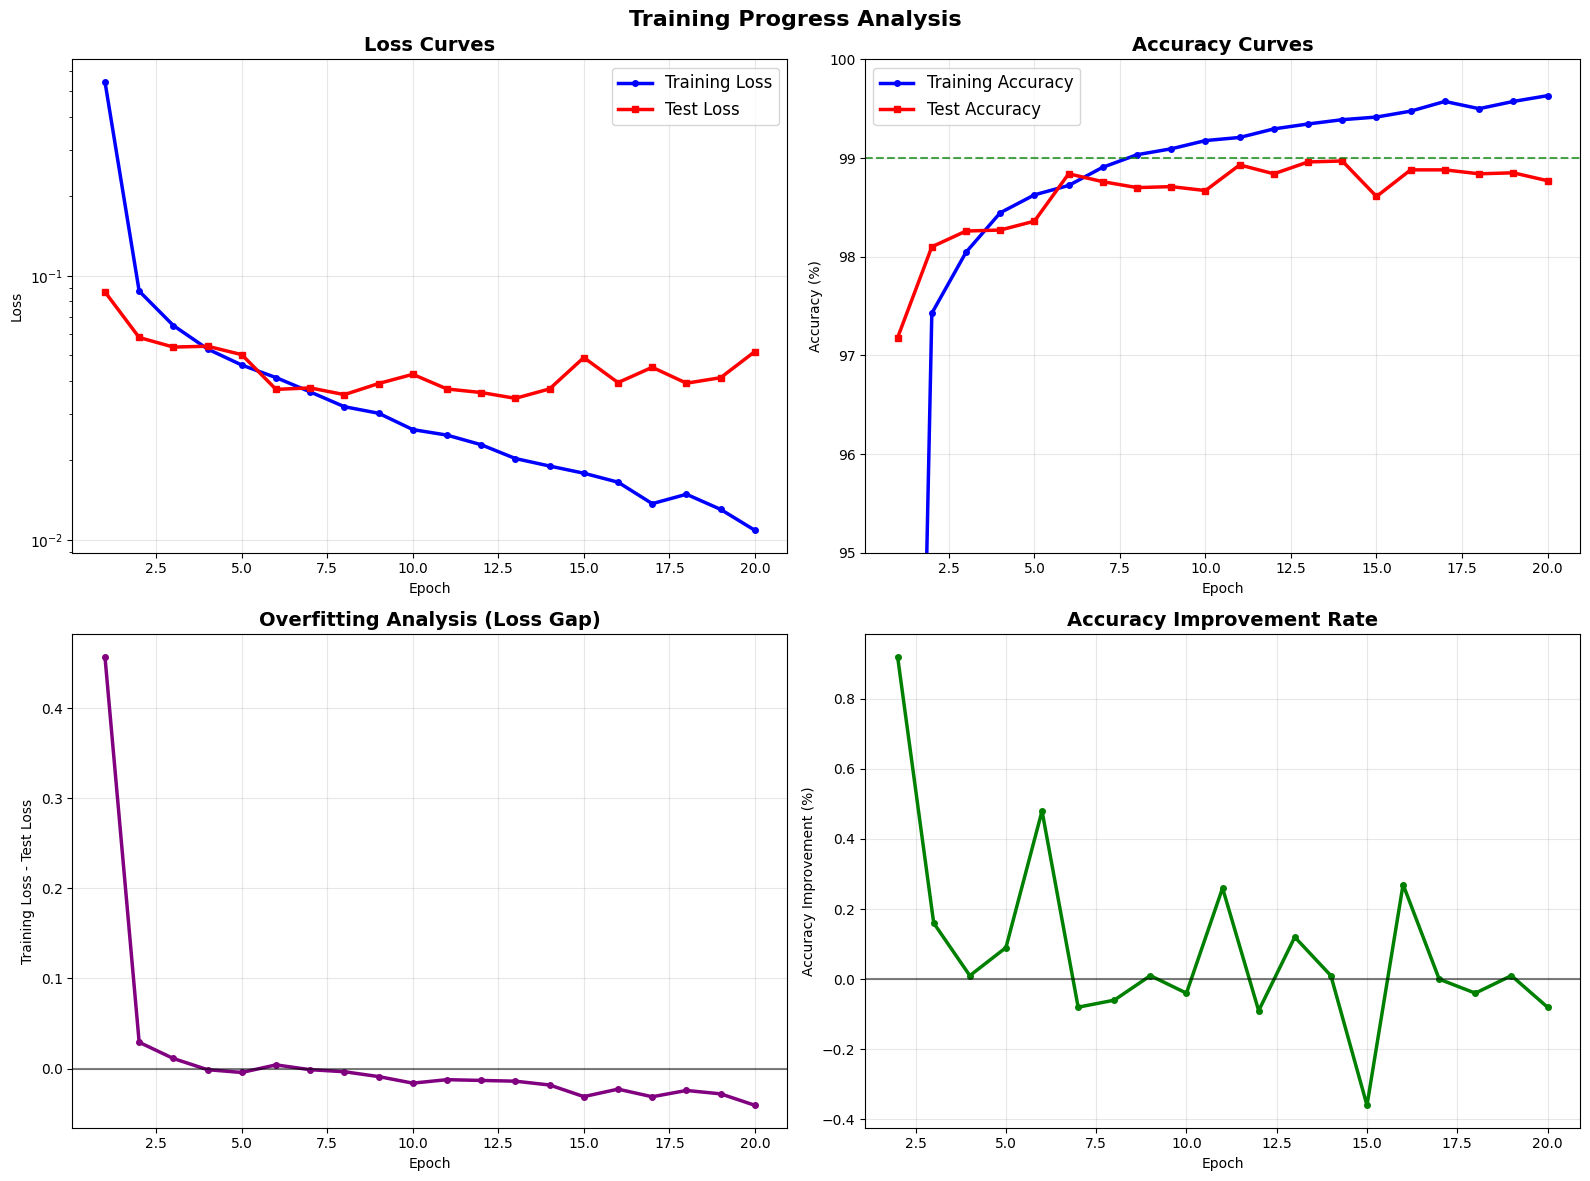


📊 Training Summary:
   Total Epochs: 20
   Best Test Accuracy: 98.97%
   Final Test Accuracy: 98.77%
   Best Test Loss: 0.0344
   Final Test Loss: 0.0517


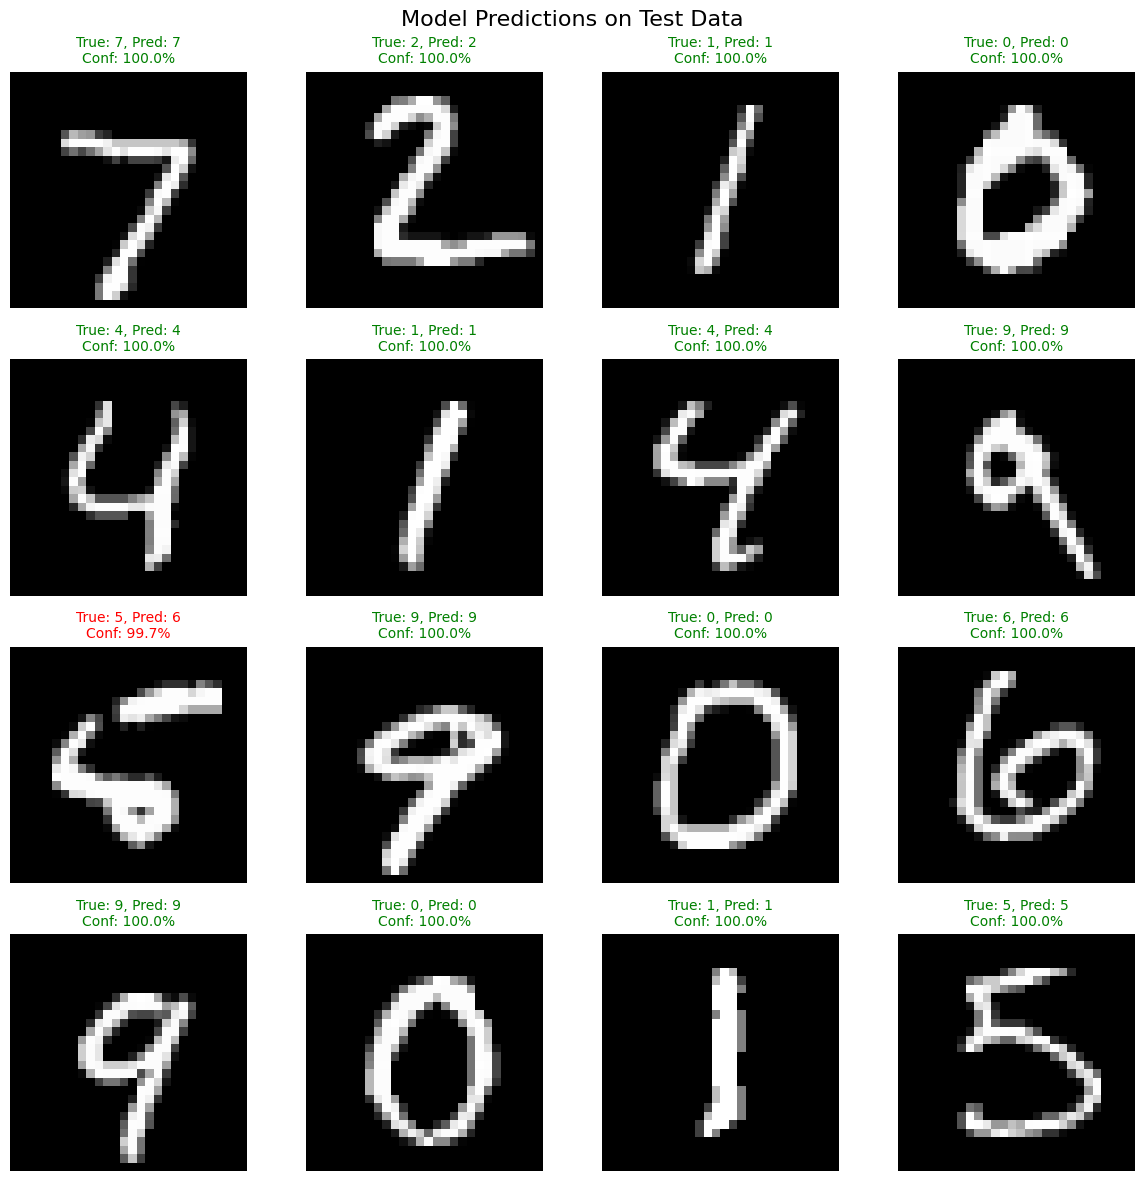

Accuracy on displayed samples: 15/16 (93.8%)


In [19]:
# Create visualizations
if len(epochs) > 0:
    plot_training_metrics(epochs, train_losses, test_losses, train_accuracies, test_accuracies)
    show_predictions(model, device, test_loader)
else:
    print("⚠️  Please run the training cell first.")
